In [14]:
#Load part_e_training_data.csv into a pandas DataFrame and display the first 5 rows
import pandas as pd
import matplotlib.pyplot as plt
import importlib, newton
importlib.reload(newton)
from newton import newton_barrier_eq, newton_barrier_phase1
import numpy as np
from io import StringIO

df = pd.read_csv('part_e_training_data.csv')
print(df)

X = df[['x_1', 'x_2']].values  # Shape: (n_samples, 2)
y = df['y'].values              # Shape: (n_samples,)

n_features = X.shape[1]
n_samples = X.shape[0]

print(f"\nDataset: {n_samples} samples, {n_features} features")
print(f"Class distribution: {np.sum(y==1)} positive, {np.sum(y==-1)} negative")


         x_1       x_2  y
0   3.624345  1.388244  1
1   1.471828  0.927031  1
2   2.865408 -0.301539  1
3   3.744812  1.238793  1
4   2.319039  1.750630  1
5   3.462108 -0.060141  1
6   1.677583  1.615946  1
7   3.133769  0.900109  1
8   1.827572  1.122142  1
9   2.042214  2.582815  1
10 -3.100619 -0.855276 -1
11 -1.098409 -1.497506 -1
12 -1.099144 -2.683728 -1
13 -2.122890 -2.935769 -1
14 -2.267888 -1.469645 -1
15 -2.691661 -2.396754 -1
16 -2.687173 -2.845206 -1
17 -2.671246 -2.012665 -1
18 -3.117310 -1.765584 -1
19 -0.340198 -1.257956 -1

Dataset: 20 samples, 2 features
Class distribution: 10 positive, 10 negative


In [2]:
# --------------- SVM objective --------------------
def f_0(w_aug):
    w = w_aug[:-1]
    b = w_aug[-1]
    # Add tiny regularization on b to prevent singular Hessian
    return 0.5 * np.dot(w, w) + 1e-8 * b**2

def grad_f_0(w_aug):
    w = w_aug[:-1]
    b = w_aug[-1]
    g = np.zeros_like(w_aug)
    g[:-1] = w
    g[-1] = 2e-8 * b  # Gradient of regularization
    return g

def hess_f_0(w_aug):
    H = np.zeros((len(w_aug), len(w_aug)))
    H[:-1, :-1] = np.eye(len(w_aug) - 1)
    H[-1, -1] = 2e-8  # Small regularization on bias to prevent singularity
    return H


# --------------- SVM constraints --------------------
def h(w_aug):
    w = w_aug[:-1]
    b = w_aug[-1]
    return 1 - y * (X @ w + b)          # vector length = n_samples

def grad_h(w_aug):
    # Returns gradient matrix: shape (n_constraints, n_variables)
    grad = np.zeros((n_samples, n_features + 1))
    grad[:, :-1] = -y[:, None] * X
    grad[:, -1] = -y
    return grad

def hess_h(w_aug):
    # Returns list of Hessian matrices (one per constraint)
    # For linear constraints, all Hessians are zero
    return [np.zeros((n_features + 1, n_features + 1)) for _ in range(n_samples)]


# --------------- PHASE I --------------------
print("Starting Phase I to find feasible point...")

# Start with zeros
x0 = np.zeros(n_features + 1)

try:
    # We increased regularization in newton.py to 0.5*||x||^2 to prevent numerical explosion
    x_feasible, phase1_iters, phase1_path = newton_barrier_phase1(
        x0, h, grad_h, hess_h,
        t_0=1.0, mu=10.0, eps=1e-6,
        max_outer=50, max_inner=100,
        early_tol=-1e-4  # Stop as soon as we are strictly feasible
    )
    
    print(f"\n✓ Phase I completed in {phase1_iters} iterations")
    print(f"  Feasible point: w={x_feasible[:-1]}, b={x_feasible[-1]:.6f}")
    print(f"  max h(x) = {np.max(h(x_feasible)):.6f}")
    print(f"  min margin = {np.min(y * (X @ x_feasible[:-1] + x_feasible[-1])):.6f}")
    
    if np.max(h(x_feasible)) > 0:
        print("\n ERROR: Dataset does not appear to be linearly separable!")
        print("Phase I could not find a point with h(x) < 0.")
        # Stop here if infeasible
    else:
        # --------------- PHASE II --------------------
        print("\nStarting Phase II to optimize...")

        x_star, iters, path = newton_barrier_eq(
            x_feasible, f_0, grad_f_0, hess_f_0,
            h, grad_h, hess_h,
            t_0=1.0, mu=10.0, eps=1e-6,
            max_outer=30, max_inner=50
        )
        
        w_star = x_star[:-1]
        b_star = x_star[-1]
        
        print(f"\n✓ Phase II completed in {iters} iterations")
        print(f"\nOptimal classifier:")
        print(f"  w* = {w_star}")
        print(f"  b* = {b_star:.6f}")
        print(f"  ||w*|| = {np.linalg.norm(w_star):.6f}")
        print(f"\nObjective (ignoring regularization): {0.5 * np.dot(w_star, w_star):.6f}")
        print(f"Constraint satisfaction:")
        print(f"  max h(x*) = {np.max(h(x_star)):.6f}")
        print(f"  min margin = {np.min(y * (X @ w_star + b_star)):.6f}")
        
        if np.max(h(x_star)) > 1e-3:
            print("WARNING: Final solution violates constraints!")

except Exception as e:
    print(f"Optimization failed: {e}")
    import traceback
    traceback.print_exc()


Starting Phase I to find feasible point...

✓ Phase I completed in 2 iterations
  Feasible point: w=[1.54034846 1.297783  ], b=-0.215716
  max h(x) = -1.372294
  min margin = 2.372294

Starting Phase II to optimize...

✓ Phase II completed in 8 iterations

Optimal classifier:
  w* = [0.4661508 0.5287552]
  b* = -0.176266
  ||w*|| = 0.704896

Objective (ignoring regularization): 0.248439
Constraint satisfaction:
  max h(x*) = -0.000000
  min margin = 1.000000

✓ Phase II completed in 8 iterations

Optimal classifier:
  w* = [0.4661508 0.5287552]
  b* = -0.176266
  ||w*|| = 0.704896

Objective (ignoring regularization): 0.248439
Constraint satisfaction:
  max h(x*) = -0.000000
  min margin = 1.000000

✓ Phase II completed in 8 iterations

Optimal classifier:
  w* = [0.4661508 0.5287552]
  b* = -0.176266
  ||w*|| = 0.704896

Objective (ignoring regularization): 0.248439
Constraint satisfaction:
  max h(x*) = -0.000000
  min margin = 1.000000


In [13]:
test_data = [np.array([-2,1]), np.array([3,0])]
for point in test_data:
    decision_value = np.dot(w_star, point) + b_star
    predicted_class = 1 if decision_value >= 0 else -1
    print(f'Test Point {point}: Decision Value = {decision_value:.4f}, Predicted Class = {predicted_class}')

Test Point [-2  1]: Decision Value = -0.5798, Predicted Class = -1
Test Point [3 0]: Decision Value = 1.2222, Predicted Class = 1


<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
C:\Users\shaiq\AppData\Local\Temp\ipykernel_11048\1999191408.py:22: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x1_plot, get_x2(x1_plot, 1), 'k--', linewidth=1, label='Margins ($w^Tx + b = \pm 1$)')


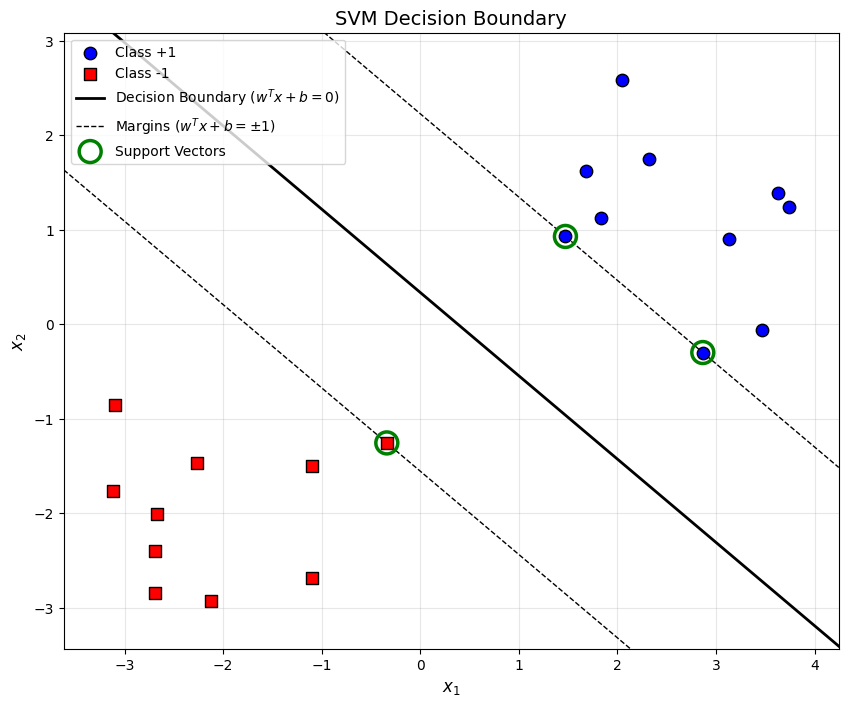


Objective: 0.2484, Margin Width: 1.4186


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: SVM Decision Boundary in Data Space ---
ax = axes[0]

# 1. Plot data points
ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Class +1', s=80, edgecolors='k', zorder=3)
ax.scatter(X[y==-1, 0], X[y==-1, 1], c='red', label='Class -1', s=80, edgecolors='k', marker='s', zorder=3)

# 2. Plot Decision Boundary and Margins
x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
x1_plot = np.linspace(x1_min, x1_max, 100)

def get_x2(x1, val):
    return (val - b_star - w_star[0] * x1) / w_star[1]

# Decision boundary (val=0)
ax.plot(x1_plot, get_x2(x1_plot, 0), 'k-', linewidth=2, label='Decision Boundary')

# Margins (val=1 and val=-1)
ax.plot(x1_plot, get_x2(x1_plot, 1), 'k--', linewidth=1, label='Margins')
ax.plot(x1_plot, get_x2(x1_plot, -1), 'k--', linewidth=1)

# 3. Highlight Support Vectors and Margin Violators
# Support vectors: points where margin <= 1 + tol (i.e. active constraints or violators)
margins = y * (X @ w_star + b_star)
sv_indices = np.where(margins < 1.01)[0]

if len(sv_indices) > 0:
    ax.scatter(X[sv_indices, 0], X[sv_indices, 1], s=200, facecolors='none', 
                edgecolors='green', linewidth=2, label='Support Vectors / Violators', zorder=4)

ax.set_xlim(x1_min, x1_max)
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
ax.set_ylim(y_min, y_max)
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
margin_width = 2.0 / np.linalg.norm(w_star)
ax.set_title(f'Soft Margin SVM (C={C})\nMargin Width: {margin_width:.4f}', fontsize=14)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)


# --- Plot 2: Optimization Path of w (Parameter Space) ---
ax = axes[1]

# Extract w path from z path
w_path = np.array([p[:2] for p in path])

ax.plot(w_path[:, 0], w_path[:, 1], 'o-', color='purple', linewidth=1.5, markersize=4, label='Newton Path ($w$)')
ax.plot(w_path[0, 0], w_path[0, 1], 'g^', markersize=10, label='Start')
ax.plot(w_star[0], w_star[1], 'r*', markersize=15, label='Optimal $w^*$')

# Annotate steps
if len(w_path) < 20:
    for i, txt in enumerate(range(len(w_path))):
        ax.annotate(txt, (w_path[i, 0], w_path[i, 1]), xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('$w_1$', fontsize=12)
ax.set_ylabel('$w_2$', fontsize=12)
ax.set_title('Optimization Trajectory of Weights $w$', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')

plt.tight_layout()
plt.show()


In [ ]:
csv_data = """x1,x2,y
2.0,3.0,-1
1.5,5.0,-1
3.0,2.5,-1
4.5,4.0,-1
2.5,4.5,-1
1.0,3.5,-1
5.0,3.5,-1
8.0,7.0,1
7.0,8.5,1
6.5,10.5,1
9.5,8.0,1
8.5,9.5,1
7.5,10.0,1
6.0,9.0,1
4.0,4.5,1
7.0,7.5,-1
1.0,9.0,-1
10.0,2.0,1
5.5,5.5,1
5.0,6.0,-1
"""

# Read the CSV data into a pandas DataFrame
df = pd.read_csv(StringIO(csv_data))

# Separate features (X) and labels (y) for SVM
X = df[['x1', 'x2']].values
y = df['y'].values

# Update dimensions for downstream cells
n_features = X.shape[1]
n_samples = X.shape[0]

print(f"Synthetic dataset loaded: {n_samples} samples, {n_features} features")
print(df.head())


[[ 2.   3. ]
 [ 1.5  5. ]
 [ 3.   2.5]
 [ 4.5  4. ]
 [ 2.5  4.5]
 [ 1.   3.5]
 [ 5.   3.5]
 [ 8.   7. ]
 [ 7.   8.5]
 [ 6.5 10.5]
 [ 9.5  8. ]
 [ 8.5  9.5]
 [ 7.5 10. ]
 [ 6.   9. ]
 [ 4.   4.5]
 [ 7.   7.5]
 [ 1.   9. ]
 [10.   2. ]
 [ 5.5  5.5]
 [ 5.   6. ]]


In [32]:
# --------------- SOFT MARGIN SVM: Compare C --------------------
dim_w = X.shape[1]
dim_b = 1
n_samples = X.shape[0]
dim_xi = n_samples
dim_total = dim_w + dim_b + dim_xi

results = []
Cs = [0.01, 0.1, 1.0, 10.0]

print("Running soft-margin SVM for different values of C...")

def unpack(z):
    w = z[:dim_w]
    b = z[dim_w]
    xi = z[dim_w+1:]
    return w, b, xi

def get_problem_funcs(C_val):
    def f_0(z):
        w, b, xi = unpack(z)
        return 0.5 * np.dot(w, w) + C_val * np.sum(xi) + 1e-8 * b**2 + 1e-8 * np.dot(xi, xi)
    def grad_f_0(z):
        w, b, xi = unpack(z)
        g = np.zeros(dim_total)
        g[:dim_w] = w
        g[dim_w] = 2e-8 * b
        g[dim_w+1:] = C_val + 2e-8 * xi
        return g
    def hess_f_0(z):
        H = np.zeros((dim_total, dim_total))
        H[:dim_w, :dim_w] = np.eye(dim_w)
        H[dim_w, dim_w] = 2e-8
        H[dim_w+1:, dim_w+1:] = 2e-8 * np.eye(dim_xi)
        return H
    return f_0, grad_f_0, hess_f_0

def h(z):
    w, b, xi = unpack(z)
    h1 = 1 - xi - y * (X @ w + b)
    h2 = -xi
    return np.concatenate([h1, h2])

def grad_h(z):
    grad = np.zeros((2 * n_samples, dim_total))
    grad[:n_samples, :dim_w] = -y[:, None] * X
    grad[:n_samples, dim_w] = -y
    grad[:n_samples, dim_w+1:] = -np.eye(n_samples)
    grad[n_samples:, dim_w+1:] = -np.eye(n_samples)
    return grad

def hess_h(z):
    return [np.zeros((dim_total, dim_total)) for _ in range(2 * n_samples)]

for C_val in Cs:
    f_0, grad_f_0, hess_f_0 = get_problem_funcs(C_val)
    z0 = np.zeros(dim_total)
    z0[dim_w+1:] = 2.0
    try:
        z_star, iters, path = newton_barrier_eq(
            z0, f_0, grad_f_0, hess_f_0,
            h, grad_h, hess_h,
            t_0=1.0, mu=10.0, eps=1e-6,
            max_outer=30, max_inner=50
        )
        w_star, b_star, xi_star = unpack(z_star)
        margins = y * (X @ w_star + b_star)
        support_mask = margins <= 1.0 + 1e-6
        misclassified_mask = margins < 0.0
        margin_width = 2.0 / np.linalg.norm(w_star)
        results.append({
            'C': C_val,
            'w': w_star.copy(),
            'b': float(b_star),
            'xi': xi_star.copy(),
            'iters': iters,
            'margin_width': margin_width,
            'margins': margins,
            'support_idx': np.where(support_mask)[0],
            'mis_idx': np.where(misclassified_mask)[0],
            'path': path
        })
        print(
            f"C={C_val:>6.2f}: ||w||={np.linalg.norm(w_star):.4f}, margin={margin_width:.4f}, "
            f"support={support_mask.sum()}, misclassified={misclassified_mask.sum()}"
        )
    except Exception as e:
        print(f"C={C_val}: optimisation failed ({e})")

Running soft-margin SVM for different values of C...
C=  0.01: ||w||=0.2600, margin=7.6927, support=15, misclassified=3
C=  0.10: ||w||=0.3818, margin=5.2382, support=9, misclassified=3
C=  1.00: ||w||=0.5287, margin=3.7831, support=8, misclassified=3
C=  0.01: ||w||=0.2600, margin=7.6927, support=15, misclassified=3
C=  0.10: ||w||=0.3818, margin=5.2382, support=9, misclassified=3
C=  1.00: ||w||=0.5287, margin=3.7831, support=8, misclassified=3
C= 10.00: ||w||=0.5287, margin=3.7831, support=8, misclassified=3
C= 10.00: ||w||=0.5287, margin=3.7831, support=8, misclassified=3


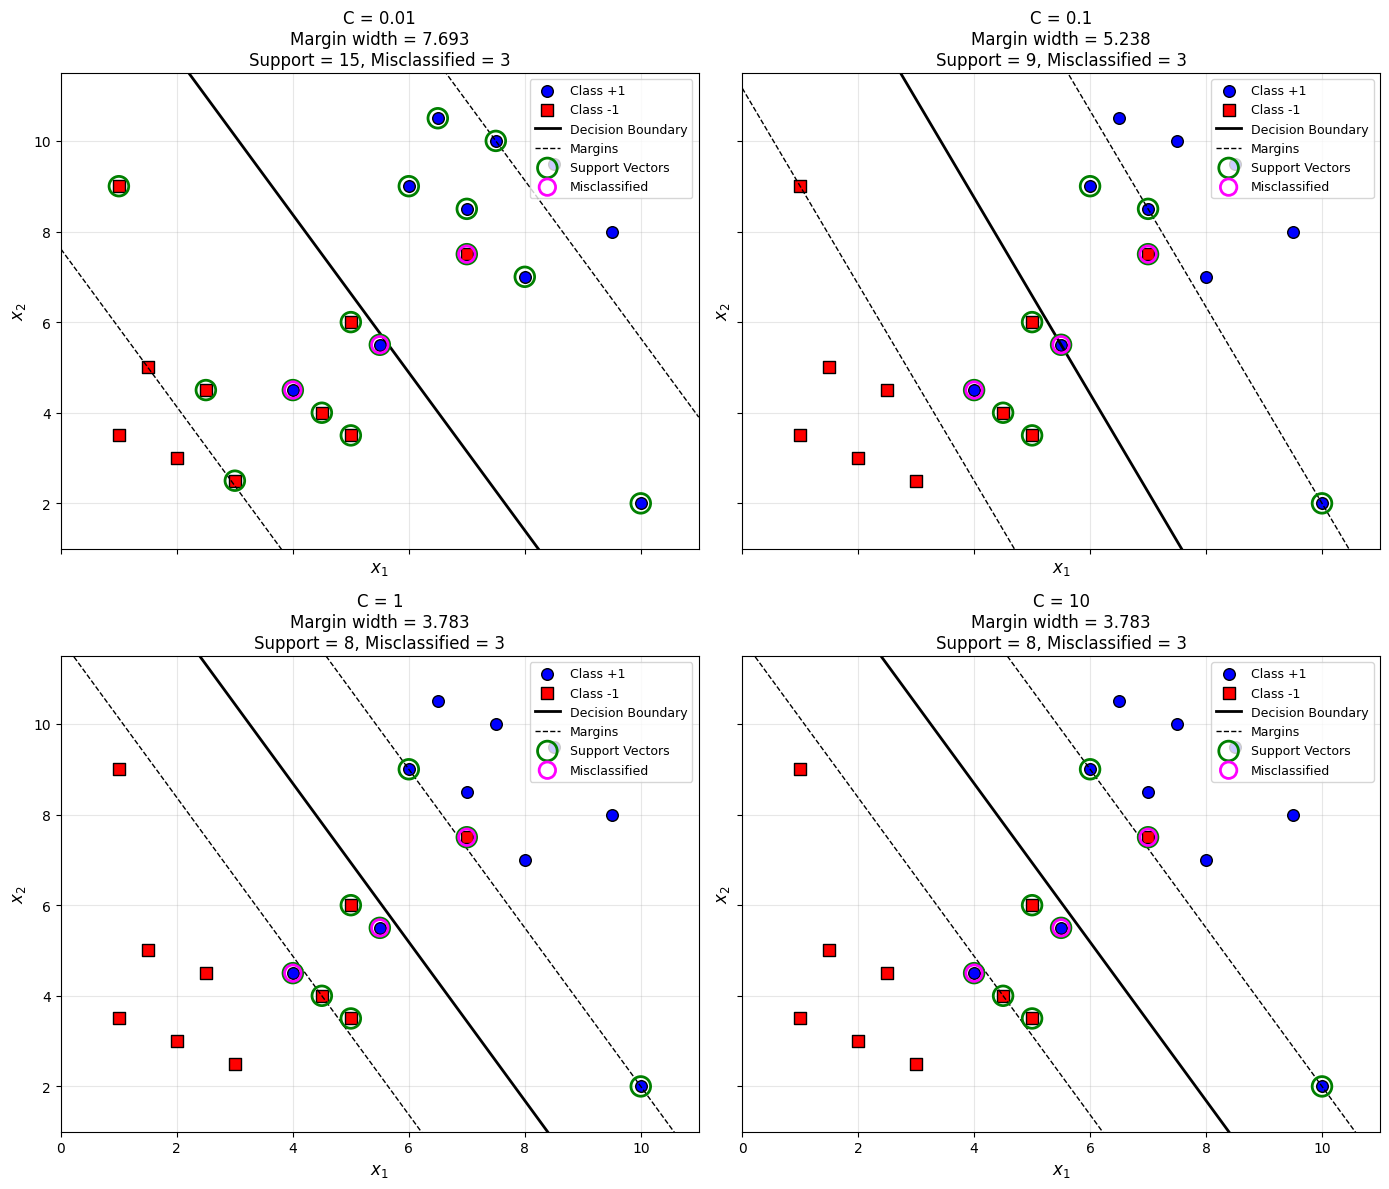


Comparison across C:
    C  ||w||  Margin width (2/||w||)  Support vectors  Misclassified  Max slack xi
 0.01 0.2600                  7.6927               15              3        1.5637
 0.10 0.3818                  5.2382                9              3        1.8400
 1.00 0.5287                  3.7831                8              3        2.0984
10.00 0.5287                  3.7831                8              3        2.0984


In [33]:
# --------------- VISUALISATION: Effect of C on Soft Margin SVM --------------------
if len(results) == 0:
    raise RuntimeError("No optimisation results available. Run the previous cell first.")

rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for idx, ax in enumerate(axes):
    if idx >= len(results):
        ax.axis('off')
        continue

    res = results[idx]
    w_star = res['w']
    b_star = res['b']
    C_val = res['C']
    margins = res['margins']
    support_idx = res['support_idx']
    mis_idx = res['mis_idx']

    ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Class +1', s=70, edgecolors='k', zorder=2)
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='red', label='Class -1', s=70, edgecolors='k', marker='s', zorder=2)

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_plot = np.linspace(x1_min, x1_max, 100)

    if abs(w_star[1]) < 1e-8:
        ax.axvline(-b_star / w_star[0], color='k', linewidth=2, label='Decision Boundary')
    else:
        def get_x2(x1, val):
            return (val - b_star - w_star[0] * x1) / w_star[1]
        ax.plot(x1_plot, get_x2(x1_plot, 0), 'k-', linewidth=2, label='Decision Boundary')
        ax.plot(x1_plot, get_x2(x1_plot, 1), 'k--', linewidth=1, label='Margins')
        ax.plot(x1_plot, get_x2(x1_plot, -1), 'k--', linewidth=1)

    if len(support_idx) > 0:
        ax.scatter(X[support_idx, 0], X[support_idx, 1], s=200, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors', zorder=3)
    if len(mis_idx) > 0:
        ax.scatter(X[mis_idx, 0], X[mis_idx, 1], s=140, facecolors='none', edgecolors='magenta', linewidth=2, label='Misclassified', zorder=4)

    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(f"C = {C_val:g}\nMargin width = {res['margin_width']:.3f}\nSupport = {len(support_idx)}, Misclassified = {len(mis_idx)}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'C': [res['C'] for res in results],
    '||w||': [np.linalg.norm(res['w']) for res in results],
    'Margin width (2/||w||)': [res['margin_width'] for res in results],
    'Support vectors': [len(res['support_idx']) for res in results],
    'Misclassified': [len(res['mis_idx']) for res in results],
    'Max slack xi': [np.max(res['xi']) for res in results]
})
print("\nComparison across C:")
print(summary.round(4).to_string(index=False))

Evaluating influence of different slack norms at C = 1.0...
        L1: ||w||=0.5287, margin=3.7831, support=8, misclassified=3
        L2: ||w||=0.2754, margin=7.2619, support=15, misclassified=3
        L1: ||w||=0.5287, margin=3.7831, support=8, misclassified=3
        L2: ||w||=0.2754, margin=7.2619, support=15, misclassified=3
L_infinity: ||w||=0.0504, margin=39.6835, support=20, misclassified=3
L_infinity: ||w||=0.0504, margin=39.6835, support=20, misclassified=3

Slack norm comparison at C = 1.0:
      norm  ||w||  margin_width  support  misclassified  max_xi
        L1 0.5287        3.7831        8              3  2.0984
        L2 0.2754        7.2619       15              3  1.5771
L_infinity 0.0504       39.6835       20              3  1.0982

Slack norm comparison at C = 1.0:
      norm  ||w||  margin_width  support  misclassified  max_xi
        L1 0.5287        3.7831        8              3  2.0984
        L2 0.2754        7.2619       15              3  1.5771
L_infini

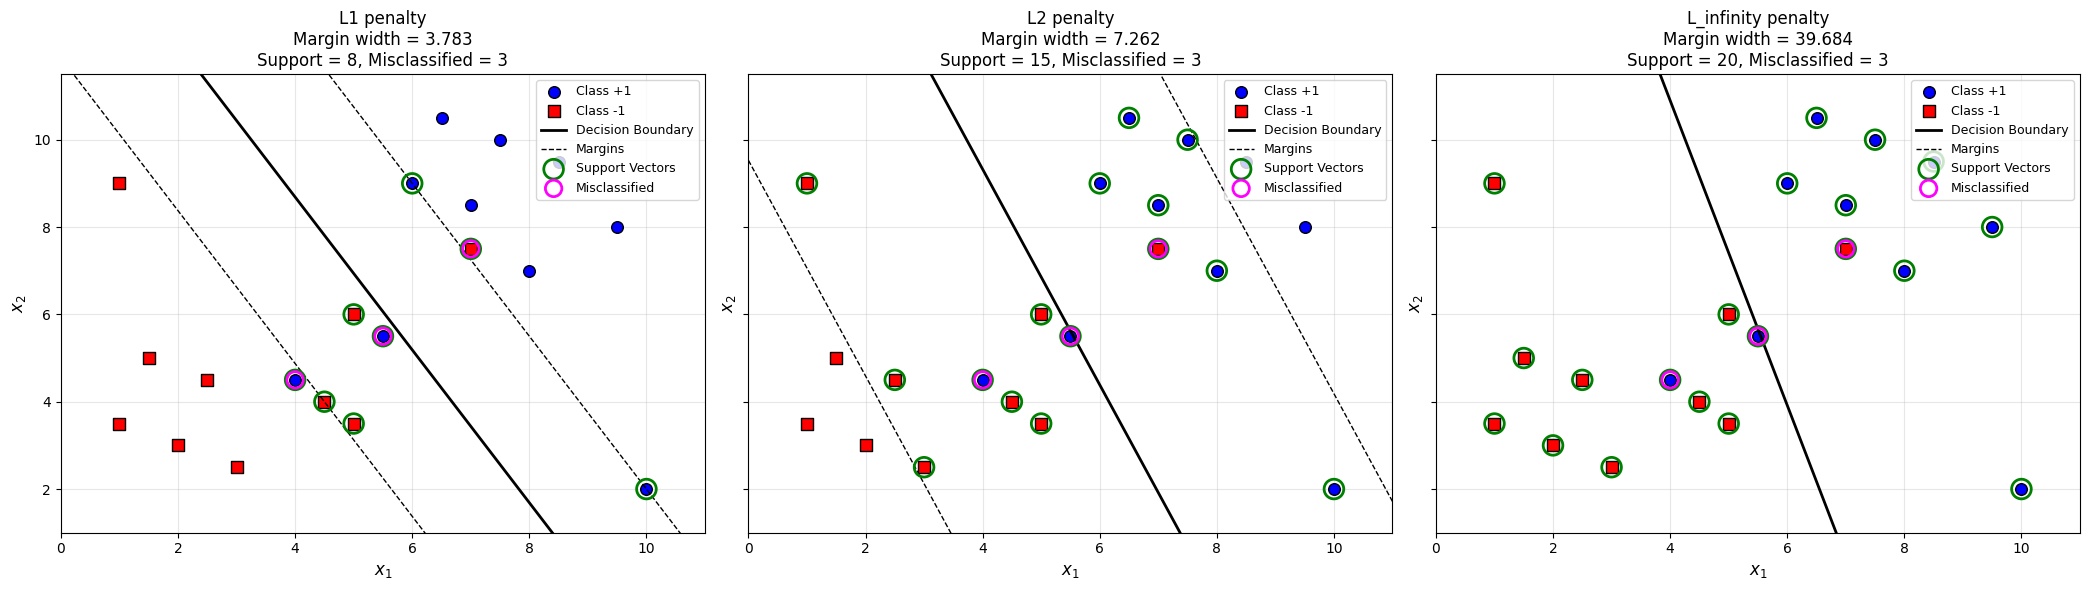

In [35]:
# --------------- ANALYSIS: Effect of Slack Norm Choice --------------------
print("Evaluating influence of different slack norms at C = 1.0...")

tau = 0.1  # Temperature for smooth max used in the L_infinity surrogate

def penalty_l1(xi):
    value = np.sum(xi)
    grad = np.ones_like(xi)
    hess = np.zeros((len(xi), len(xi)))
    return value, grad, hess

def penalty_l2(xi):
    sq_norm = np.dot(xi, xi) + 1e-12
    norm = np.sqrt(sq_norm)
    grad = xi / norm
    hess = np.eye(len(xi)) / norm - np.outer(xi, xi) / (norm ** 3)
    return norm, grad, hess

def penalty_linf(xi):
    shifted = (xi - np.max(xi)) / tau
    exp_shift = np.exp(shifted)
    denom = np.sum(exp_shift)
    probs = exp_shift / denom
    value = tau * (np.log(denom) + np.max(xi) / tau)
    grad = probs
    hess = (np.diag(probs) - np.outer(probs, probs)) / tau
    return value, grad, hess

norm_penalties = {
    "L1": penalty_l1,
    "L2": penalty_l2,
    "L_infinity": penalty_linf
}

norm_results = []
C_eval = 1.0

for norm_name, penalty_fn in norm_penalties.items():
    def f_0(z):
        w, b, xi = unpack(z)
        penalty, _, _ = penalty_fn(xi)
        return 0.5 * np.dot(w, w) + C_eval * penalty + 1e-8 * b**2 + 1e-8 * np.dot(xi, xi)

    def grad_f_0(z):
        w, b, xi = unpack(z)
        _, grad_xi, _ = penalty_fn(xi)
        g = np.zeros(dim_total)
        g[:dim_w] = w
        g[dim_w] = 2e-8 * b
        g[dim_w+1:] = C_eval * grad_xi + 2e-8 * xi
        return g

    def hess_f_0(z):
        _, _, xi = unpack(z)
        _, _, hess_xi = penalty_fn(xi)
        H = np.zeros((dim_total, dim_total))
        H[:dim_w, :dim_w] = np.eye(dim_w)
        H[dim_w, dim_w] = 2e-8
        H[dim_w+1:, dim_w+1:] = C_eval * hess_xi + 2e-8 * np.eye(dim_xi)
        return H

    z0 = np.zeros(dim_total)
    z0[dim_w+1:] = 2.0

    try:
        z_star, iters, path = newton_barrier_eq(
            z0, f_0, grad_f_0, hess_f_0,
            h, grad_h, hess_h,
            t_0=1.0, mu=10.0, eps=1e-6,
            max_outer=30, max_inner=50
        )
        w_star, b_star, xi_star = unpack(z_star)
        margins = y * (X @ w_star + b_star)
        support_mask = margins <= 1.0 + 1e-6
        misclassified_mask = margins < 0.0
        norm_results.append({
            'norm': norm_name,
            'w': w_star.copy(),
            'b': float(b_star),
            'xi': xi_star.copy(),
            'iters': iters,
            '||w||': np.linalg.norm(w_star),
            'margin_width': 2.0 / np.linalg.norm(w_star),
            'support': int(support_mask.sum()),
            'misclassified': int(misclassified_mask.sum()),
            'max_xi': float(np.max(xi_star)),
            'margins': margins,
            'support_idx': np.where(support_mask)[0],
            'mis_idx': np.where(misclassified_mask)[0]
        })
        print(
            f"{norm_name:>10s}: ||w||={np.linalg.norm(w_star):.4f}, margin={2.0/np.linalg.norm(w_star):.4f}, "
            f"support={support_mask.sum()}, misclassified={misclassified_mask.sum()}"
        )
    except Exception as e:
        print(f"{norm_name}: optimisation failed ({e})")

if norm_results:
    comparison = pd.DataFrame(norm_results)[[
        'norm', '||w||', 'margin_width', 'support', 'misclassified', 'max_xi'
    ]]
    print("\nSlack norm comparison at C = 1.0:")
    print(comparison.round(4).to_string(index=False))

    fig, axes = plt.subplots(1, len(norm_results), figsize=(7 * len(norm_results), 6), sharex=True, sharey=True)
    if len(norm_results) == 1:
        axes = [axes]

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    x1_plot = np.linspace(x1_min, x1_max, 100)

    for ax, res in zip(axes, norm_results):
        w_star = res['w']
        b_star = res['b']
        margins = res['margins']
        support_idx = res['support_idx']
        mis_idx = res['mis_idx']
        norm_name = res['norm']

        ax.scatter(X[y==1, 0], X[y==1, 1], c='blue', label='Class +1', s=70, edgecolors='k', zorder=2)
        ax.scatter(X[y==-1, 0], X[y==-1, 1], c='red', label='Class -1', s=70, edgecolors='k', marker='s', zorder=2)

        if abs(w_star[1]) < 1e-8:
            ax.axvline(-b_star / w_star[0], color='k', linewidth=2, label='Decision Boundary')
        else:
            def get_x2(x1, val):
                return (val - b_star - w_star[0] * x1) / w_star[1]
            ax.plot(x1_plot, get_x2(x1_plot, 0), 'k-', linewidth=2, label='Decision Boundary')
            ax.plot(x1_plot, get_x2(x1_plot, 1), 'k--', linewidth=1, label='Margins')
            ax.plot(x1_plot, get_x2(x1_plot, -1), 'k--', linewidth=1)

        if len(support_idx) > 0:
            ax.scatter(X[support_idx, 0], X[support_idx, 1], s=200, facecolors='none', edgecolors='green', linewidth=2, label='Support Vectors', zorder=3)
        if len(mis_idx) > 0:
            ax.scatter(X[mis_idx, 0], X[mis_idx, 1], s=140, facecolors='none', edgecolors='magenta', linewidth=2, label='Misclassified', zorder=4)

        ax.set_xlim(x1_min, x1_max)
        ax.set_ylim(x2_min, x2_max)
        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_ylabel('$x_2$', fontsize=12)
        ax.set_title(
            f"{norm_name} penalty\nMargin width = {res['margin_width']:.3f}\nSupport = {res['support']}, Misclassified = {res['misclassified']}"
        )
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()